# Machine Learning Models


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
DATA_DIR = Path('.')
OUTPUT_DIR = Path('models')
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:
features_df = pd.read_csv(DATA_DIR / 'ai_productivity_features1.csv')
targets_df = pd.read_csv(DATA_DIR / 'ai_productivity_targets1.csv')

productivity_df = features_df.merge(
    targets_df,
    on='Employee_ID',
    how='inner',
    validate='one_to_one'
)

print('Features shape:', features_df.shape)
print('Targets shape:', targets_df.shape)
print('Joined shape:', productivity_df.shape)
productivity_df.head()


Features shape: (4500, 15)
Targets shape: (4500, 3)
Joined shape: (4500, 17)


,Employee_ID,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score,productivity_score,burnout_risk_level
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,Writer,19,11.8,28.5,19.2,1.4,High,1.9,2.3,0.20,2,7.1,4.8,10.00,81.0,High
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,Designer,4,10.8,24.1,23.3,2.6,Low,8.0,9.8,1.82,3,3.4,5.5,6.78,59.2,Medium
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,Developer,6,25.9,69.4,10.0,1.4,Medium,6.8,8.9,5.52,5,4.6,3.8,9.66,62.4,High
3,14511660-d78a-453f-9449-f17cd239ec27,Manager,20,7.9,17.2,25.1,0.2,High,3.5,8.6,1.14,5,5.6,3.9,10.00,76.8,High
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,Developer,15,8.6,20.6,20.1,1.4,Low,5.9,5.3,2.75,10,1.0,7.4,5.38,53.7,Medium


In [3]:
target = 'productivity_score'

feature_cols = [
    'job_role',
    'experience_years',
    'ai_tool_usage_hours_per_week',
    'tasks_automated_percent',
    'manual_work_hours_per_week',
    'learning_time_hours_per_week',
    'deadline_pressure_level',
    'meeting_hours_per_week',
    'collaboration_hours_per_week',
    'error_rate_percent',
    'task_complexity_score',
    'focus_hours_per_day',
    'work_life_balance_score',
    'burnout_risk_score'
]

X = productivity_df[feature_cols]
y = productivity_df[target]

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target:', target)


Numeric features: ['experience_years', 'ai_tool_usage_hours_per_week', 'tasks_automated_percent', 'manual_work_hours_per_week', 'learning_time_hours_per_week', 'meeting_hours_per_week', 'collaboration_hours_per_week', 'error_rate_percent', 'task_complexity_score', 'focus_hours_per_day', 'work_life_balance_score', 'burnout_risk_score']
Categorical features: ['job_role', 'deadline_pressure_level']
Target: productivity_score


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])


Training rows: 3600
Testing rows: 900


In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## Model 1: Linear Regression


In [6]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_metrics = {
    'model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test, linear_predictions),
    'RMSE': np.sqrt(mean_squared_error(y_test, linear_predictions)),
    'R2': r2_score(y_test, linear_predictions)
}

linear_metrics


{'model': 'Linear Regression',
 'MAE': 3.940221026722677,
 'RMSE': 4.909435496210267,
 'R2': 0.8788212164923045}

## Model 2: Random Forest Regressor


In [7]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)

rf_metrics = {
    'model': 'Random Forest Regressor',
    'MAE': mean_absolute_error(y_test, rf_predictions),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_predictions)),
    'R2': r2_score(y_test, rf_predictions)
}

rf_metrics


{'model': 'Random Forest Regressor',
 'MAE': 4.681034357177022,
 'RMSE': 5.791672830167586,
 'R2': 0.8313557597621271}

## Compare Regression Models

Lower MAE/RMSE is better. Higher R-squared is better.


In [8]:
model_comparison = pd.DataFrame([linear_metrics, rf_metrics]).round(3)
model_comparison


,model,MAE,RMSE,R2
0,Linear Regression,3.940,4.909,0.879
1,Random Forest Regressor,4.681,5.792,0.831


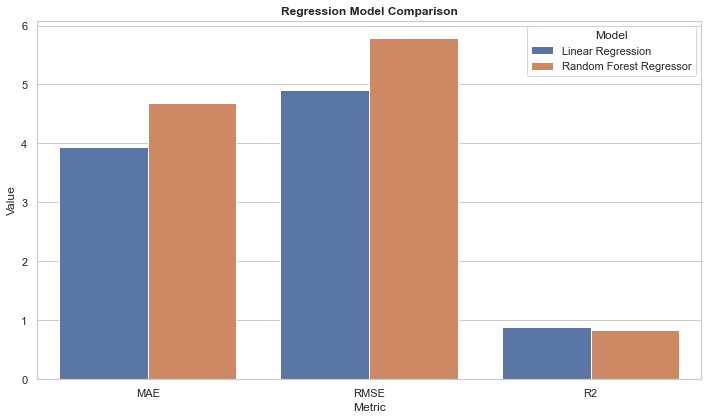

In [9]:
comparison_plot_df = model_comparison.melt(
    id_vars='model',
    value_vars=['MAE', 'RMSE', 'R2'],
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_plot_df,
    x='metric',
    y='value',
    hue='model'
)
plt.title('Regression Model Comparison')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


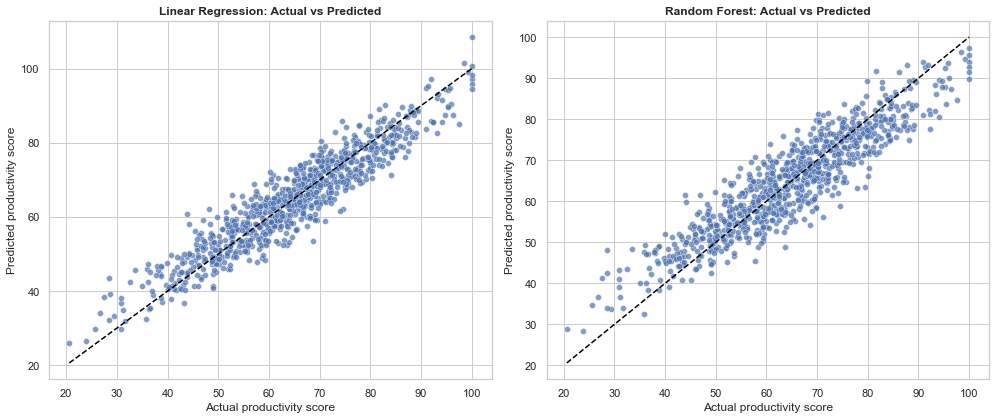

In [10]:
prediction_results = pd.DataFrame({
    'actual_productivity': y_test,
    'linear_prediction': linear_predictions,
    'random_forest_prediction': rf_predictions
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=prediction_results,
    x='actual_productivity',
    y='linear_prediction',
    alpha=0.7,
    ax=axes[0]
)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual productivity score')
axes[0].set_ylabel('Predicted productivity score')

sns.scatterplot(
    data=prediction_results,
    x='actual_productivity',
    y='random_forest_prediction',
    alpha=0.7,
    ax=axes[1]
)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual productivity score')
axes[1].set_ylabel('Predicted productivity score')

plt.tight_layout()
plt.show()


In [11]:
linear_feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()
linear_coefficients = linear_model.named_steps['model'].coef_

linear_coef_df = (
    pd.DataFrame({
        'feature': linear_feature_names,
        'coefficient': linear_coefficients
    })
    .assign(abs_coefficient=lambda df: df['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
)

linear_coef_df.head(15)


,feature,coefficient,abs_coefficient
2,num__tasks_automated_percent,7.458671,7.458671
0,num__experience_years,5.693109,5.693109
9,num__focus_hours_per_day,5.502122,5.502122
11,num__burnout_risk_score,-4.664475,4.664475
7,num__error_rate_percent,-4.638202,4.638202
10,num__work_life_balance_score,-1.061806,1.061806
3,num__manual_work_hours_per_week,-0.805800,0.805800
19,cat__deadline_pressure_level_Low,0.713629,0.713629
1,num__ai_tool_usage_hours_per_week,-0.669215,0.669215
18,cat__deadline_pressure_level_High,-0.656837,0.656837


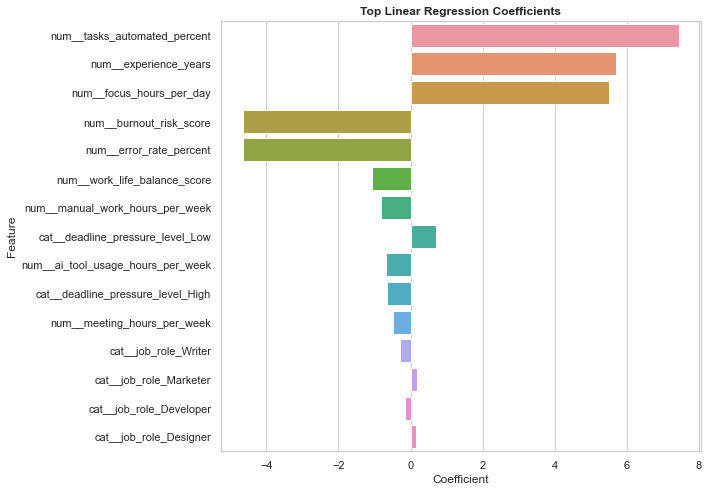

In [12]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=linear_coef_df.head(15),
    y='feature',
    x='coefficient'
)
plt.title('Top Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Random Forest Feature Importance


In [13]:
rf_feature_names = random_forest_model.named_steps['preprocessor'].get_feature_names_out()
rf_importances = random_forest_model.named_steps['model'].feature_importances_

rf_importance_df = (
    pd.DataFrame({
        'feature': rf_feature_names,
        'importance': rf_importances
    })
    .sort_values('importance', ascending=False)
)

rf_importance_df.head(15)


,feature,importance
2,num__tasks_automated_percent,0.302855
0,num__experience_years,0.198916
9,num__focus_hours_per_day,0.179982
7,num__error_rate_percent,0.106372
11,num__burnout_risk_score,0.103681
10,num__work_life_balance_score,0.023918
1,num__ai_tool_usage_hours_per_week,0.018646
5,num__meeting_hours_per_week,0.015252
3,num__manual_work_hours_per_week,0.013224
6,num__collaboration_hours_per_week,0.011478


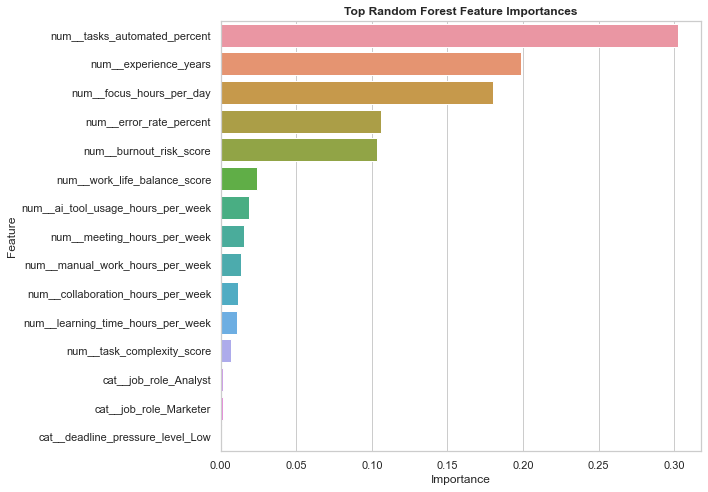

In [14]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=rf_importance_df.head(15),
    y='feature',
    x='importance'
)
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Model 3: K-Means Clustering

Grouping employees into similar work/AI behavior segments.


In [15]:
cluster_features = [
    'ai_tool_usage_hours_per_week',
    'tasks_automated_percent',
    'manual_work_hours_per_week',
    'burnout_risk_score',
    'work_life_balance_score',
    'focus_hours_per_day',
    'error_rate_percent',
    'productivity_score'
]

cluster_df = productivity_df[cluster_features].copy()

cluster_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cluster_matrix = cluster_preprocessor.fit_transform(cluster_df)
print('Clustering rows:', cluster_matrix.shape[0])
print('Clustering features:', cluster_features)


Clustering rows: 4500
Clustering features: ['ai_tool_usage_hours_per_week', 'tasks_automated_percent', 'manual_work_hours_per_week', 'burnout_risk_score', 'work_life_balance_score', 'focus_hours_per_day', 'error_rate_percent', 'productivity_score']


In [16]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(cluster_matrix)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_matrix, labels))

cluster_score_df = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette_score': silhouette_scores
})

cluster_score_df.round(3)


,k,inertia,silhouette_score
0,2,26448.249,0.229
1,3,21600.959,0.226
2,4,19437.651,0.185
3,5,17831.421,0.175
4,6,16485.060,0.173
5,7,15501.898,0.167
6,8,14776.624,0.165


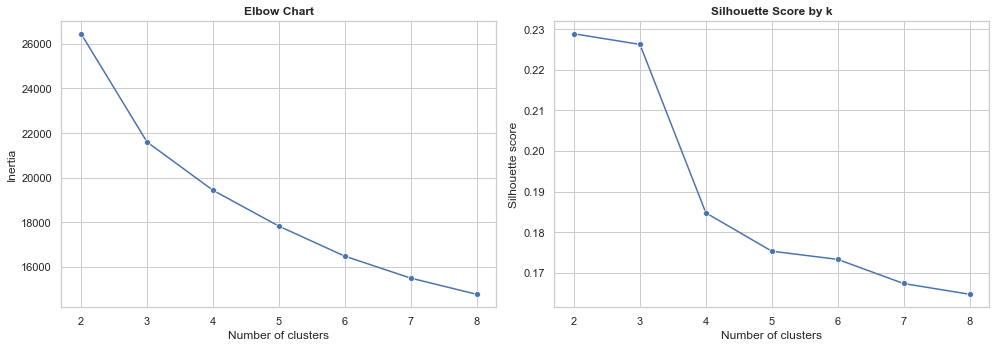

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cluster_score_df, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow Chart')
axes[0].set_xlabel('Number of clusters')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=cluster_score_df, x='k', y='silhouette_score', marker='o', ax=axes[1])
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()


In [18]:
FINAL_K = 4

kmeans_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
productivity_df['cluster'] = kmeans_model.fit_predict(cluster_matrix)

productivity_df[['Employee_ID', 'job_role', 'productivity_score', 'burnout_risk_score', 'cluster']].head()


,Employee_ID,job_role,productivity_score,burnout_risk_score,cluster
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,Writer,81.0,10.00,1
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,Designer,59.2,6.78,2
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,Developer,62.4,9.66,0
3,14511660-d78a-453f-9449-f17cd239ec27,Manager,76.8,10.00,1
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,Developer,53.7,5.38,2


In [19]:
cluster_summary = (
    productivity_df
    .groupby('cluster')
    .agg(
        employees=('Employee_ID', 'count'),
        avg_ai_hours=('ai_tool_usage_hours_per_week', 'mean'),
        avg_tasks_automated=('tasks_automated_percent', 'mean'),
        avg_manual_hours=('manual_work_hours_per_week', 'mean'),
        avg_productivity=('productivity_score', 'mean'),
        avg_burnout=('burnout_risk_score', 'mean'),
        avg_work_life_balance=('work_life_balance_score', 'mean'),
        avg_focus_hours=('focus_hours_per_day', 'mean'),
        avg_error_rate=('error_rate_percent', 'mean')
    )
    .round(2)
)

cluster_summary


,employees,avg_ai_hours,avg_tasks_automated,avg_manual_hours,avg_productivity,avg_burnout,avg_work_life_balance,avg_focus_hours,avg_error_rate
cluster,,,,,,,,,
0,873,18.48,47.46,14.63,78.16,8.00,5.22,5.09,2.41
1,1320,11.86,29.39,22.53,64.60,9.54,3.81,5.05,2.22
2,1108,7.69,19.58,22.04,70.46,6.08,6.99,5.12,1.87
3,1199,5.22,12.24,28.14,50.62,9.40,3.28,3.62,1.95


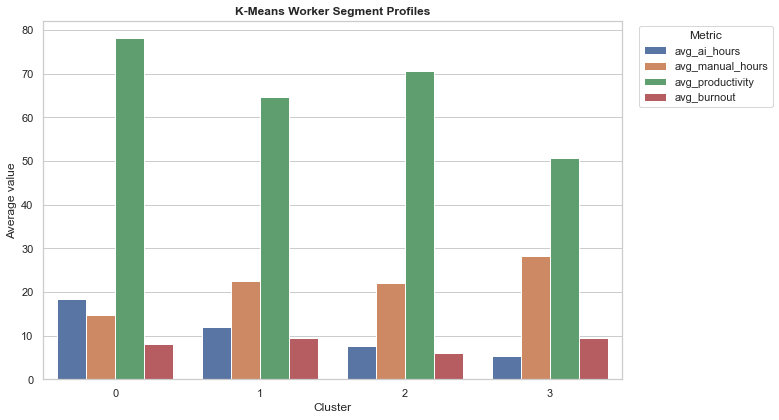

In [20]:
cluster_plot_df = cluster_summary.reset_index().melt(
    id_vars='cluster',
    value_vars=['avg_ai_hours', 'avg_manual_hours', 'avg_productivity', 'avg_burnout'],
    var_name='metric',
    value_name='average_value'
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=cluster_plot_df,
    x='cluster',
    y='average_value',
    hue='metric'
)
plt.title('K-Means Worker Segment Profiles')
plt.xlabel('Cluster')
plt.ylabel('Average value')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


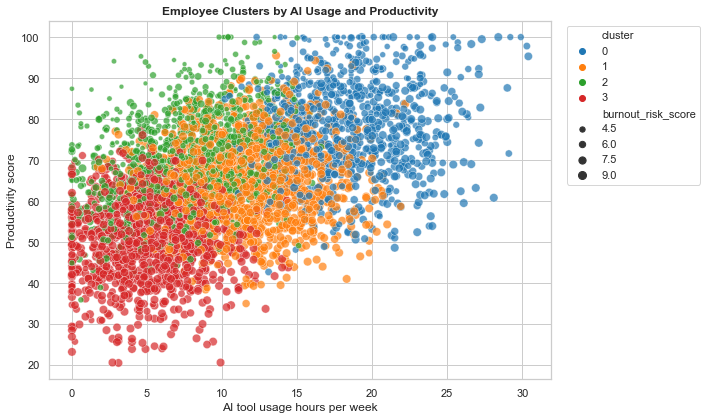

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=productivity_df,
    x='ai_tool_usage_hours_per_week',
    y='productivity_score',
    hue='cluster',
    size='burnout_risk_score',
    palette='tab10',
    alpha=0.7
)
plt.title('Employee Clusters by AI Usage and Productivity')
plt.xlabel('AI tool usage hours per week')
plt.ylabel('Productivity score')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Save Dashboard Summary Outputs

- `model_comparison.csv`
- `cluster_summary.csv`


In [22]:
model_comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
cluster_summary.to_csv(OUTPUT_DIR / 'cluster_summary.csv')

print('Saved dashboard summary files to:', OUTPUT_DIR.resolve())


Saved dashboard summary files to: /Users/cameronbarker/Documents/Capstone/models
